# Processing disentanglement data

## Imports and setup

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
import pandas as pd
import os
sys.path.append("/Users/andrin/switchdrive/Institution/Soares-Santos/Positioners/Tilt_test_all/TiltTest/LAB-positioner-tilt/scripts/")
import spotfinderB as spotB
#plt.style.use("/Users/sean/.config/matplotlib/matplotlibrc")
data_dir = "/Users/andrin/switchdrive/Institution/Soares-Santos/Positioners/Tilt_test_all/TiltTest/data/metrologyScan4/"
figure_dir = "/Users/andrin/switchdrive/Institution/Soares-Santos/Positioners/Tilt_test_all/TiltTest/figures"

In [40]:
xDir = "xScan"
xRange = np.arange(0,21,step=5).astype(str)

yDir = "yScan"
yRange = np.arange(0,21,step=5).astype(str)

Pseudocode for the data processing
```
# For each scan directory
    # Instantiate data storage object for entire scan directory
    # Iterate over each sub directory (numbers)
        # Instantiate data storage object for scan position
        # grab only .tif files in sub directory
        # For each .tif file
            # Run Spotfinder with optimal parameters
            # Store data in sub-directory data object
        # Store data for the scan directory
    # Save data product for the scan directory
```

## Process the data

In [41]:
names = ['peaks',"x","y","fwhm","energy","radius",
         'peaks_std',"x_std","y_std","fwhm_std","energy_std","radius_std",
         "stage_pos"]
formats = ['f8','f8','f8','f8','f8','f8','f8','f8','f8','f8','f8','f8',"i4"]
nm_fm = []
for n,f in zip(names,formats):
    nm_fm.append((n,f))

In [42]:
%%time
verbose=False
for directory,ranges in zip([xDir,yDir],[xRange,yRange]):
    scanDir = os.path.join(data_dir,directory)
    print(f"Scanning {scanDir}")
    
    scanResult = np.array([],dtype=nm_fm)

    for p in ranges:
        subDir = os.path.join(scanDir,p)
        print(f"Scanning {subDir}")
        tifFiles = np.array(os.listdir(subDir))[np.array([x.endswith(".tif") for x in os.listdir(subDir)])]
        print(f"Found {len(tifFiles)} tif files in {subDir}")
        subDir_nm_fm = nm_fm[0:6]
        subDirCents = np.array([])
        for f in tifFiles:
            finder = spotB.SpotFinder(file_path=os.path.join(subDir,f),max_counts=4000,min_energy=25,fboxsize=150,gaussian=True,gaussian_sig=4,li=True)
            centroid = finder.get_centroids()
            centroid['radius'] = centroid['fwhm']/(2*np.sqrt(2*np.log(2)))
            for k,v in zip(centroid.keys(),centroid.values()):
                centroid[k] = v[0]
            subDirCents = np.append(subDirCents,centroid)
        vals = [tuple(x.values()) for x in subDirCents]
        centroidResult = np.array(vals,dtype=subDir_nm_fm)

        thisRange = []

        for n in centroidResult.dtype.names:
            median = np.median(centroidResult[n])
            thisRange.append(median)
            
        for n in centroidResult.dtype.names:
            std = np.std(centroidResult[n])
            thisRange.append(std)

        thisRange.append(int(p))

        scanResult = np.append(scanResult, np.array(tuple(thisRange),dtype=nm_fm))

        print(f"Results for {subDir} are stored in memory.")

    # Save the result
    saveFile = f"{directory}_results_2"
    np.save(os.path.join(data_dir,saveFile),scanResult)

    print(f"Results for {scanDir} were saved to {os.path.join(data_dir,saveFile)}.npy.")
    

Scanning /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/xScan
Scanning /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/xScan/0
Found 5 tif files in /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/xScan/0
Results for /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/xScan/0 are stored in memory.
Scanning /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/xScan/5
Found 5 tif files in /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/xScan/5
Results for /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/xScan/5 are stored in memory.
Scanning /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/xScan/10
Found 5 tif files in /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/xScan/10
Results for /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/xScan/10 are stored in memory.
Scanning /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/xScan/15
Found 5 tif files in /Users/andrin/Documents/UZH/TiltTest/data/metrologyS

/Users/andrin/Documents/UZH/TiltTest/LAB-positioner-tilt/scripts/spotfinderB.py:44: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  p, _ = optimize.leastsq(errorfunction, params)


Results for /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/yScan/20 are stored in memory.
Results for /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/yScan were saved to /Users/andrin/Documents/UZH/TiltTest/data/metrologyScan4/yScan_results_2.npy.
CPU times: user 42.9 s, sys: 387 ms, total: 43.3 s
Wall time: 45.3 s


## Make some plots

In [43]:
resultFiles = np.array(os.listdir(data_dir))[np.array([x.endswith(".npy") for x in os.listdir(data_dir)])]

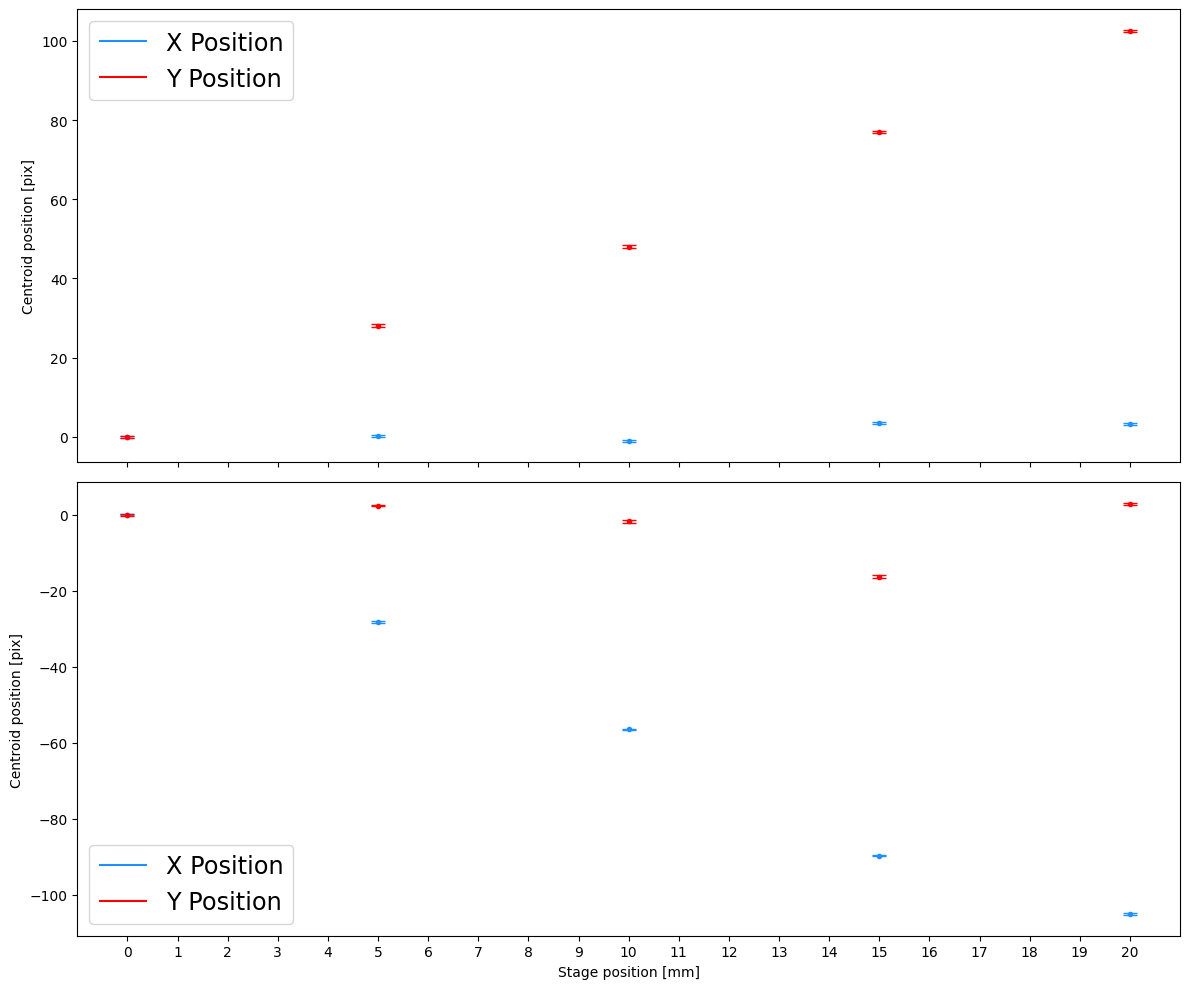

In [44]:
fig,axs = plt.subplots(nrows=2,figsize=[12,10],sharex=True)

outDir = os.path.join(data_dir,"results")

os.makedirs(outDir,exist_ok=True)

for file,ax,maskVal in zip(resultFiles,axs.flatten(),[None,None]):

    result = np.load(os.path.join(data_dir,file))
    useResult = result[result['stage_pos']!=maskVal]
    
    l1 = ax.errorbar(useResult['stage_pos'],useResult['x']-useResult['x'][0],yerr=useResult['x_std'],color='dodgerblue',ls='',label='X Position',
                    capsize=5,marker=".")
    ax.set_ylabel("Centroid position [pix]")
    # ax2 = ax.twinx()
    l2 = ax.errorbar(useResult['stage_pos'],useResult['y']-useResult['y'][0],yerr=useResult['y_std'],color='red',ls='',label='Y Position',
                     capsize=5,marker=".")
    # ax2.set_ylabel("Centroid y position [pix]")
    ax.legend([l1[2],l2[2]],["X Position","Y Position"],fontsize='xx-large')
    ax.set_xticks(np.arange(21))
ax.set_xlabel("Stage position [mm]")
fig.tight_layout()
fig.savefig(os.path.join(outDir,"xyScanResult.jpg"),dpi=300)

In [45]:
result['stage_pos'],result['x']

(array([ 0,  5, 10, 15, 20], dtype=int32),
 array([2139.57321584, 2111.2922936 , 2083.08371106, 2049.85958584,
        2034.46988321]))

In [46]:
# df = pd.DataFrame(result)

xResult = pd.DataFrame(np.load(os.path.join(data_dir,resultFiles[0])))
yResult = pd.DataFrame(np.load(os.path.join(data_dir,resultFiles[1])))

In [47]:
np.median([np.median(np.abs(np.diff(xResult['y']))),np.median(np.abs(np.diff(yResult['x'])))]) / 5

np.float64(5.5115648009633444)

Text(0.5, 0, 'Pixel offset (rescaled to zero)')

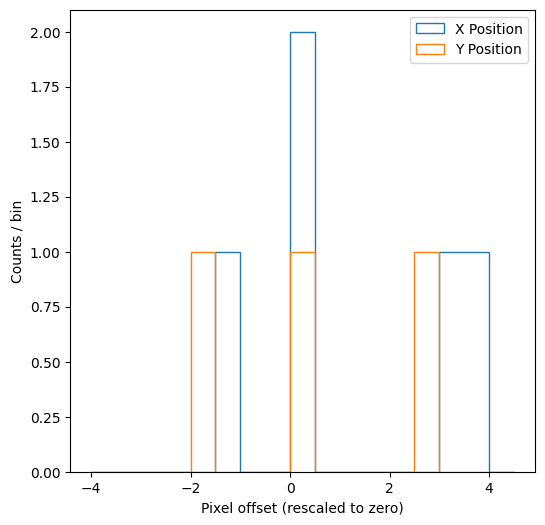

In [48]:
fig,ax = plt.subplots(nrows=1,figsize=[6,6])

for file,maskVal in zip(resultFiles,[21,5]):

    result = np.load(os.path.join(data_dir,file))
    useResult = result[result['stage_pos']!=maskVal]

    if file[0]=="x":
        ax.hist(useResult["y"]-useResult["y"][0],histtype='step',label="Y Position",bins=np.arange(-4,5,step=0.5))
    elif file[0]=="y":
        ax.hist(useResult["x"]-useResult["x"][0],histtype='step',label="X Position",bins=np.arange(-4,5,step=0.5))
ax.legend()
ax.set_ylabel("Counts / bin")
ax.set_xlabel("Pixel offset (rescaled to zero)")

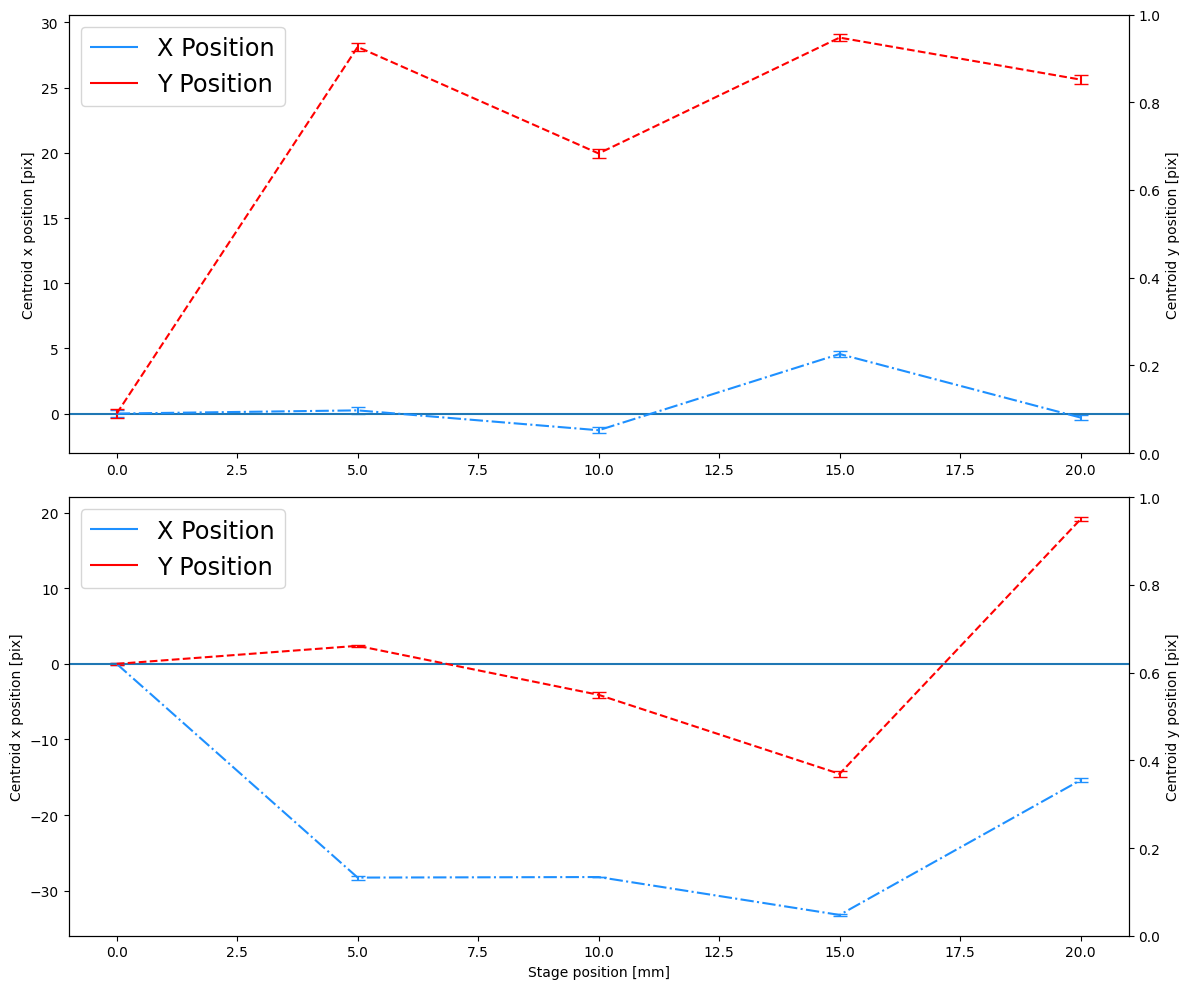

In [49]:
fig,axs = plt.subplots(nrows=2,figsize=[12,10])

for file,ax in zip(resultFiles,axs.flatten(),):

    result = np.load(os.path.join(data_dir,file))
    
    l1 = ax.errorbar(result['stage_pos'],np.diff(result['x']-result['x'][0],prepend=0),yerr=result['x_std'],color='dodgerblue',ls='-.',label='X Position',
                    capsize=5)
    ax.set_ylabel("Centroid x position [pix]")
    ax2 = ax.twinx()
    l2 = ax.errorbar(result['stage_pos'],np.diff(result['y']-result['y'][0],prepend=0),yerr=result['y_std'],color='red',ls='--',label='Y Position',
                     capsize=5)
    ax2.set_ylabel("Centroid y position [pix]")
    ax.legend([l1[2],l2[2]],["X Position","Y Position"],fontsize='xx-large',loc=2)
    ax.axhline(0)
    #ax.set_ylim(-10,10)
ax.set_xlabel("Stage position [mm]")
fig.tight_layout()
fig.savefig(os.path.join(outDir,"xyScanResult_diff.jpg"),dpi=300)